# PREDICTING CAR SELLING PRICES
by Ario, Anano and Judy

### Overview: 

We devided the notebook in 5 steps to have a clear & structured way:

1. Exploratory Data Analysis (EDA) 🔍
2. Data Preprocessing & Feature Engineering 🧼
3. Modeling: Multiple Regression Techniques 🧠
4. Model Comparison with Performance Metrics 📈
5. Final Model Selection & Interpretation 🏆


In [293]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing and modeling later
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set()

### (1) Exploratory Data Analysis (EDA) 🔍

→ Goal: understand the dataset, spot trends and potential issues.

In [294]:
# read the csv file
data = pd.read_csv('car data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Description of the variables: 
- Car_Name: name of the car, not relevant for the analysis later as feature
- Year: year in which the car was build
- Present_Price: current price of the car if it would be bought new
- Kms_Driven: kilometers that were driven with the car
- Fuel_Type: Fuel needed for the car
- Seller_Type: who sold the car (e.g. dealer)
- Transmission: automatic or manual transmission
- Owner: Number of owners the car had

- Selling_Price (dependent variable!): price at which the car was sold

(1.1) DATA OVERVIEW 🔍

In [295]:
# check the number of rows and columns of the data
data.shape

(301, 9)

In [296]:
# check the column types and null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [297]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


In [298]:
# check for missing values
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [299]:
# check unique values in each column

print (data.nunique())
print ("")
print ("Fuel Type:", data['Fuel_Type'].unique())
print ("Seller Type:", data['Seller_Type'].unique())
print ("Transmission:", data['Transmission'].unique())
print ("Owner Type:", data['Owner'].unique())

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

Fuel Type: ['Petrol' 'Diesel' 'CNG']
Seller Type: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']
Owner Type: [0 1 3]


In [300]:
#drop unnessary columns: we do not need the Car_Name column for our analysis
data.drop(['Car_Name'], axis=1, inplace=True)

In [301]:
# add care age column
data['Car_Age'] = 2025 - data['Year']
data.drop(['Year'], axis=1, inplace=True)

(1.2) TARGET VARIABLE DESTRIBUTION 🔍

In [302]:
# destribution of the target variable
data['Selling_Price'].describe()

count   301.00
mean      4.66
std       5.08
min       0.10
25%       0.90
50%       3.60
75%       6.00
max      35.00
Name: Selling_Price, dtype: float64

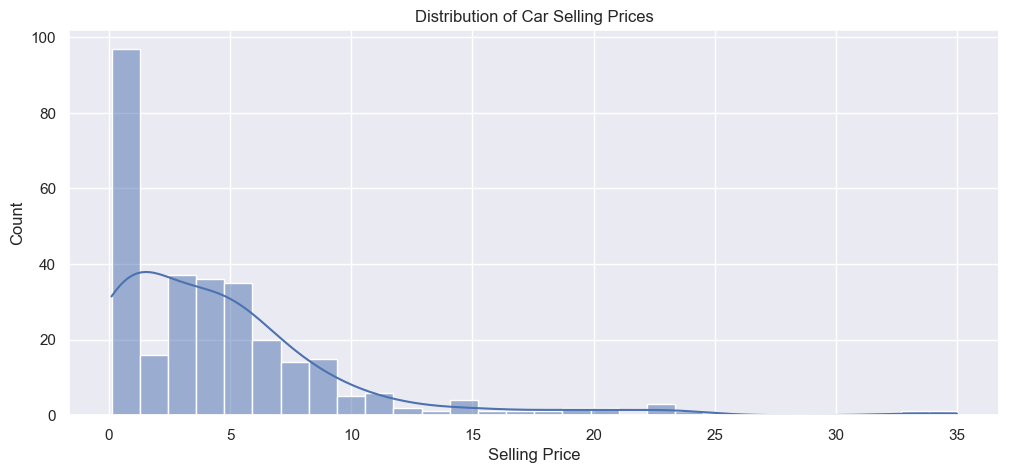

In [303]:
# check the distribution and skewness of the target variable
plt.figure(figsize=(12, 5))
sns.histplot(data['Selling_Price'], bins=30, kde=True)
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.show()

👉 The destribution is right-skewed , which most cars being sold for less than 10 units and there are a few high-price outliers, going up to ~35 untis The mean is pulled toward the high-price outliers and the model might perform poorly on lower-priced cars. There is a spike right at 0  or near 0, poissibly representing freee transfers, invalid entries or unusually cheap cars.

This can have an impact later with linear models, as linear models assume the target variable is normally distributed and the skewness therfore might affect model performance. Log Transformation might help!


(1.3)  FEATURE CORRELATION 🔍

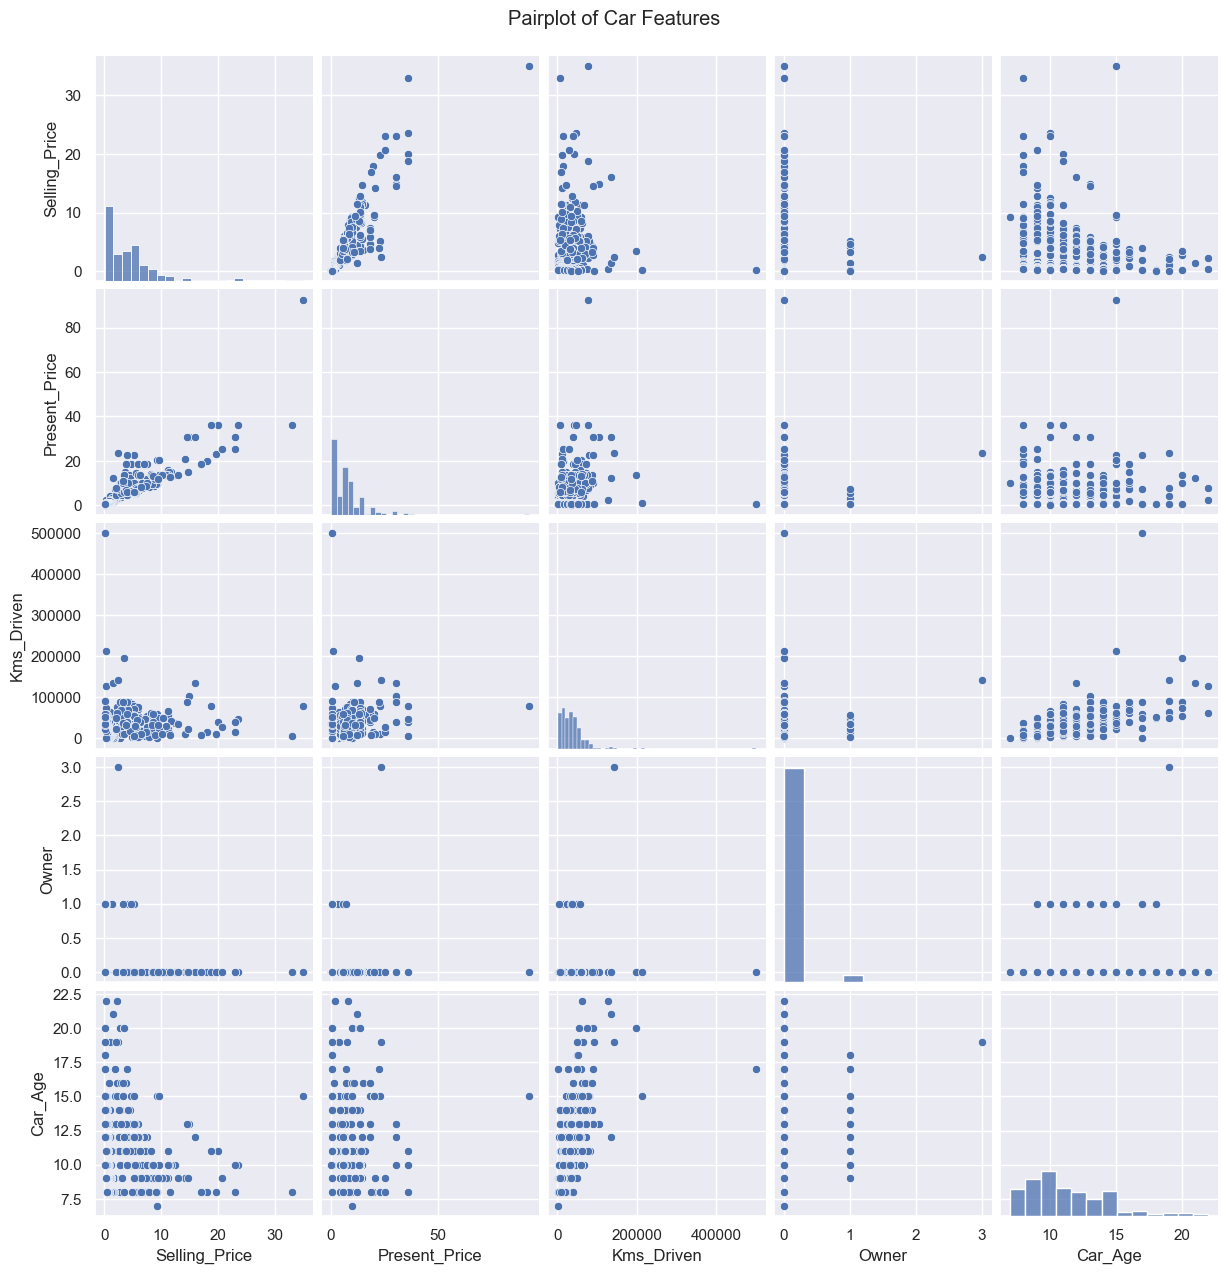

In [304]:
# pairplot to visualize the relationships between features

sns.pairplot(data)
plt.suptitle('Pairplot of Car Features', y=1.02)
plt.show()


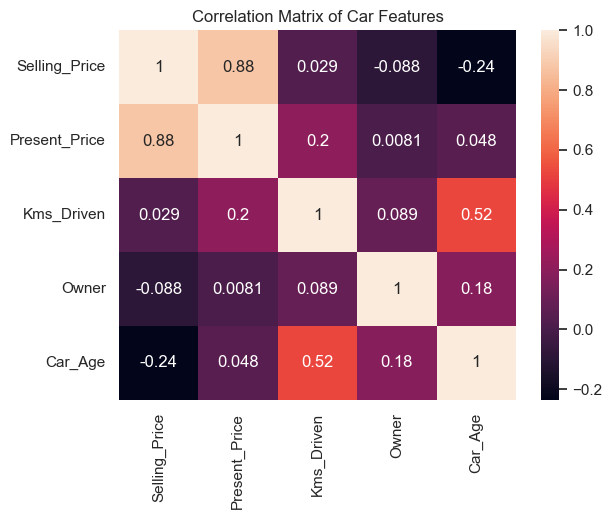

In [305]:
# correlation matrix to check the correlation between numerical features

numerical_data = data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_data.corr(), annot=True)
plt.title('Correlation Matrix of Car Features')
plt.show()

👉 From the Pairplot and corrleation matrix one can see the following:
- there seems to be a strong correlation between present price and selling price. Which makes sense, as the higher the present price is, the higher the selling price will be
- There is a moderate positive corrleation between selling price & year (0,24). This also makes sense, as older cars often depreciate in value
- Selling price & kms and selling price & owner both have a weak corrleation

(1.4) UNIVARIATE & BIVARIATE ANALYSIS 🔍

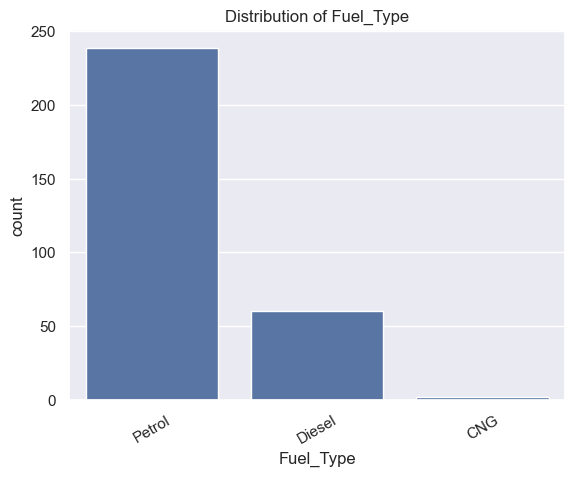

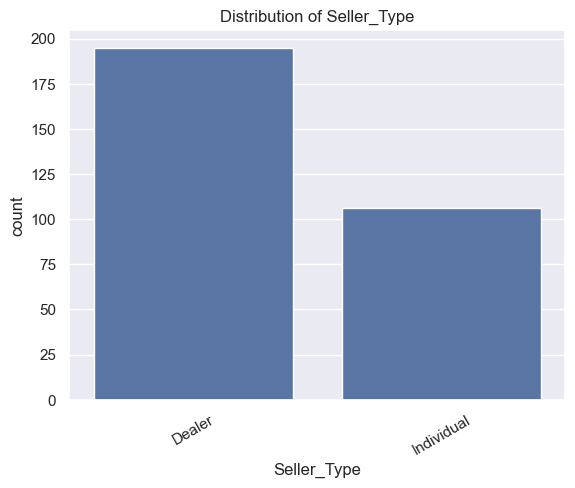

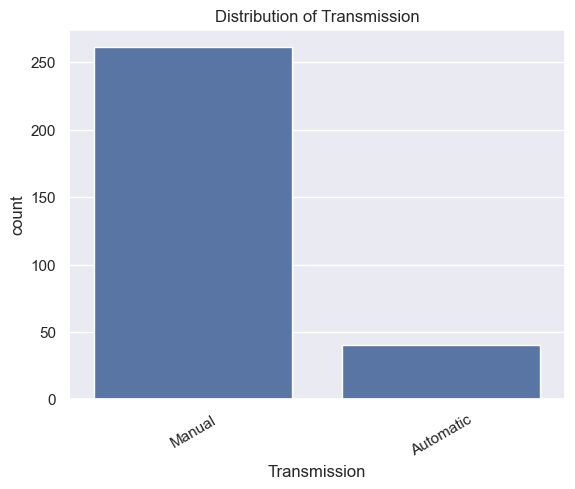

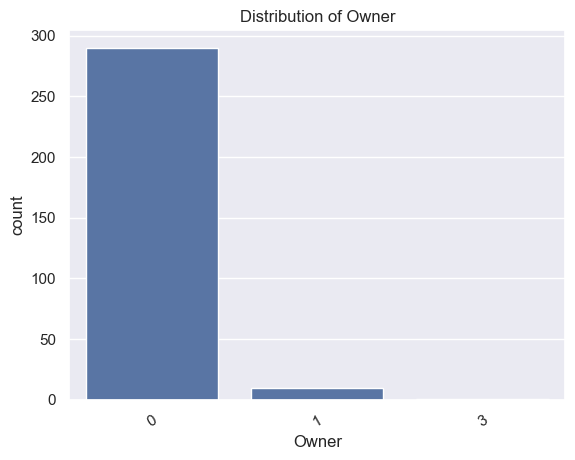

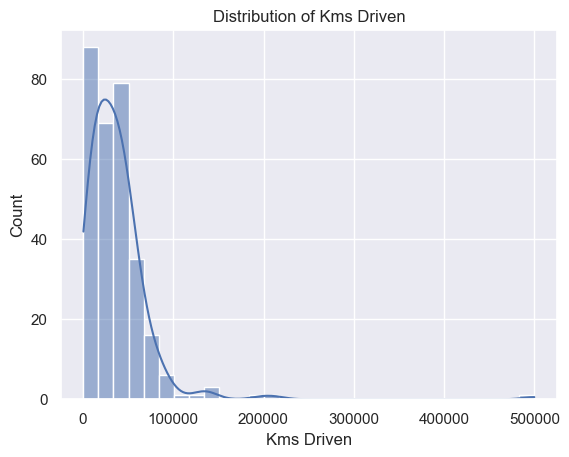

In [306]:
# Univariate for categorical features
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    sns.countplot(x=data[col])
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=30)
    plt.show()

# check the distribution for kilometers driven


sns.histplot(data['Kms_Driven'], bins=30, kde=True)
plt.title('Distribution of Kms Driven')
plt.xlabel('Kms Driven')
plt.show()


👉 From the Countplots we can see that we can have imbalanced categorical variables, so we might need to group rare categories to have a stable and good model (e.g. for owner: 0 and 1_or_more). Also Kilometers driven has high outliers, so we will later also use log transformation

### (2) Data Preprocessing & Feature Engineering 🧼

→ Goal: prepare the data for modeling

(2.1) FEATURE TRANSFORMATION 🧼

In [307]:
# simplify the Owner column: '0' and everythin >0  'more'

data['Owner'] = data['Owner'].apply(lambda x: 'More' if x > 0 else '0')

In [308]:
# one-hot encoding for categorical variables
data = pd.get_dummies(data, columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'], drop_first=True)

# Ensure binary dtypes are integers (0/1)
data = data.astype({col: 'int' for col in data.columns if data[col].dtype == 'bool'})

(2.2) OUTLIER TREATMENT 🧼

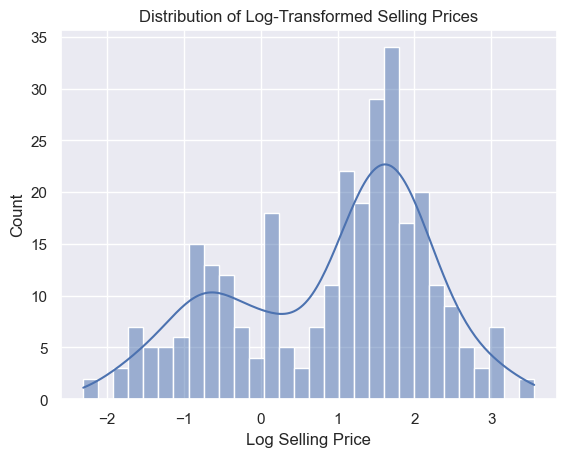

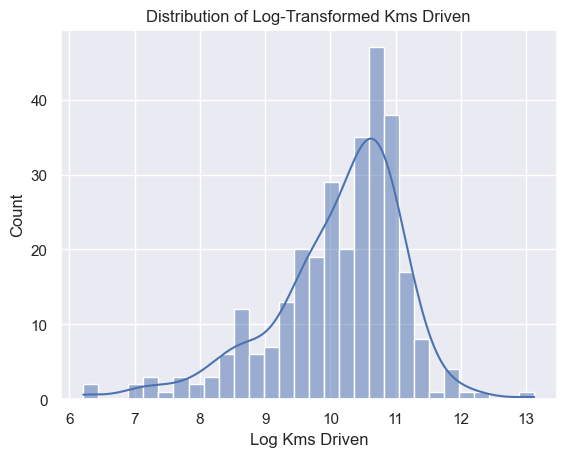

In [309]:
# to adress the right-skewed distribution of the target variable, we can apply log transformation
data['Selling_Price'] = np.log(data['Selling_Price']) 

# address the right-skewed distribution of the Kms_Driven variable
data['Kms_Driven'] = np.log(data['Kms_Driven'])

# check the distribution of the target variable after log transformation
sns.histplot(data['Selling_Price'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Selling Prices')
plt.xlabel('Log Selling Price')
plt.show()

# check the distribution of the target variable after log transformation
sns.histplot(data['Kms_Driven'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Kms Driven')
plt.xlabel('Log Kms Driven')
plt.show()


👉 kms - driven looks now better destributed, selling price also but it is stilll shifted as there are lots of values close to 0.

(2.3) TRAIN-TEST-SPLIT 🧼 

In [310]:
# define X and y
X = data.drop(['Selling_Price'], axis=1)
y = data['Selling_Price']

print(X.shape)
print(y.shape)

(301, 8)
(301,)


In [311]:
# apply the train test split  with test_size=0.3 and random_state=42

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# check the shape of the train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (210, 8)
X_test shape: (91, 8)
y_train shape: (210,)
y_test shape: (91,)


(2.4) SCALING: STANDARDIZATION FOR LINEAR MODELS 🧼

In [312]:
# We scale to features to ensure that they contribute equally to the model. It is important for Linear, KNN, and SVM models.

# before scaling
print("Before scaling:")
print("Mean of training set (first 5 features):")
print(np.mean(X_train.iloc[:, :5], axis=0))
print("")
print("Std of training set (first 5 features):")
print(np.std(X_train.iloc[:, :5], axis=0))

Before scaling:
Mean of training set (first 5 features):
Present_Price       7.41
Kms_Driven         10.12
Car_Age            11.30
Fuel_Type_Diesel    0.19
Fuel_Type_Petrol    0.80
dtype: float64

Std of training set (first 5 features):
Present_Price      8.87
Kms_Driven         1.01
Car_Age            2.86
Fuel_Type_Diesel   0.39
Fuel_Type_Petrol   0.40
dtype: float64


In [313]:
# Apply scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [314]:
#after scaling (mean should be close to 0 and std should be close to 1)
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("After scaling:")
print("Mean of scaled training set (first 5 features):")
print(scaled_df.iloc[:, :5].mean())
print("")
print("Std of scaled training set (first 5 features):")
print(scaled_df.iloc[:, :5].std())

After scaling:
Mean of scaled training set (first 5 features):
Present_Price      -0.00
Kms_Driven         -0.00
Car_Age            -0.00
Fuel_Type_Diesel   -0.00
Fuel_Type_Petrol   -0.00
dtype: float64

Std of scaled training set (first 5 features):
Present_Price      1.00
Kms_Driven         1.00
Car_Age            1.00
Fuel_Type_Diesel   1.00
Fuel_Type_Petrol   1.00
dtype: float64


Final preprocessed data:

In [315]:
data.head()

,Selling_Price,Present_Price,Kms_Driven,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_More
0,1.21,5.59,10.20,11,0,1,0,1,0
1,1.56,9.54,10.67,12,1,0,0,1,0
2,1.98,9.85,8.84,8,0,1,0,1,0
3,1.05,4.15,8.56,14,0,1,0,1,0
4,1.53,6.87,10.66,11,1,0,0,1,0


### (3) Modeling: Multiple Regression Techniques 🧠

→ Goal: explore different regression methods and optimize them

(3.1) LINEAR REGRESSION

In [316]:
from sklearn.linear_model import LinearRegression

### (4) Model Comparison with Performance Metrics 📈

→ Goal: assess model performance & compare alternatives.

### (5) Final Model Selection & Interpretation 🏆
→ Goal: justify our choice